In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import json
import seaborn as sns
import warnings
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=UserWarning)


sys.path.append("/home/iscb/wolfson/hagairavid/LocAlign")
from utils.loading import deserialize_nested_lists

In [2]:
# prefix = "2024-07-04_23-31-40_3083.csv"
# prefix = "2024-07-11_10-24-20_2720.csv"
prefix = "2024-07-17_16-01-08_3000.csv"
prefix = "2024-07-18_10-26-26_10000.csv"
prefix = "2024-07-30_10-18-28_500.csv"
prefix = "2024-08-06_18-29-52_500.csv"
prefix = "2024-08-13_18-21-51_1000.csv"
prefix = "2024-08-14_21-59-20_500.csv"
prefix = "2024-08-14_22-47-13_2000.csv"
prefix = "2024-09-10_10-06-43_2000.csv"
prefix = "2024-09-12_16-54-07_2000.csv"

# directory = "/home/iscb/wolfson/hagairavid/ligand_aligner/baseline_results/"
directory = "/home/iscb/wolfson/hagairavid/LocAlign/results/baseline_results/"
matching_files = [f for f in os.listdir(directory) if f.startswith(prefix)]

if matching_files:
    latest_file = max(matching_files, key=lambda x: os.path.getmtime(os.path.join(directory, x)))
    file_path = os.path.join(directory, latest_file)
    print("Latest file:", file_path)
else:
    print("No matching files found.")
df = pd.read_csv(file_path)


df['coverage'] = df['coverage'].astype(str)
df['rmse'] = df['rmse'].astype(str)

for col in df.columns:
    if df[col].apply(lambda x: isinstance(x, str) and x.startswith('[') and x.endswith(']')).any():
        df[col] = df[col].apply(lambda x: json.loads(x))
        df[col] = df[col].apply(lambda x: deserialize_nested_lists(x, col))

Latest file: /home/iscb/wolfson/hagairavid/LocAlign/results/baseline_results/2024-09-12_16-54-07_2000.csv


In [3]:
with_trans = df[df['n_transformations'] > 0]
with_trans.shape

(1665, 41)

In [4]:
with_trans['found_dali'] = with_trans['DaliAligner_rotations'].apply(lambda x: len(x) > 0)
with_trans['found_tm'] = with_trans['TMaligner_rotations'].apply(lambda x: len(x) > 0)
with_trans['found_bbs'] = with_trans['HardBBS_rotations'].apply(lambda x: len(x) > 0)
with_trans['found_iterative_softBBS'] = with_trans['iterative_SoftBBS_rotations'].apply(lambda x: len(x) > 0)
with_trans['found_softBBS'] = with_trans['SoftBBS_rotations'].apply(lambda x: len(x) > 0)
print(with_trans['found_dali'].value_counts())
print(with_trans['found_tm'].value_counts())
with_trans['found_all'] = with_trans['found_tm'] & with_trans['found_dali'] & with_trans['found_bbs'] & with_trans['found_iterative_softBBS']

found_dali
True     895
False    770
Name: count, dtype: int64
found_tm
True    1665
Name: count, dtype: int64


/tmp/ipykernel_2123139/2397931325.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['found_dali'] = with_trans['DaliAligner_rotations'].apply(lambda x: len(x) > 0)
/tmp/ipykernel_2123139/2397931325.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['found_tm'] = with_trans['TMaligner_rotations'].apply(lambda x: len(x) > 0)
/tmp/ipykernel_2123139/2397931325.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

## DALI

In [5]:
with_trans['only_tm'] = with_trans['found_tm'] &  with_trans['found_dali'] == False
with_trans['only_tm'].value_counts()

/tmp/ipykernel_2123139/3181294601.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['only_tm'] = with_trans['found_tm'] &  with_trans['found_dali'] == False


only_tm
False    895
True     770
Name: count, dtype: int64

/tmp/ipykernel_2123139/2657027292.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['max_bbr'] = with_trans['bbr'].apply(find_max_in_sublists)


23.225030657614088
8.344650979296274


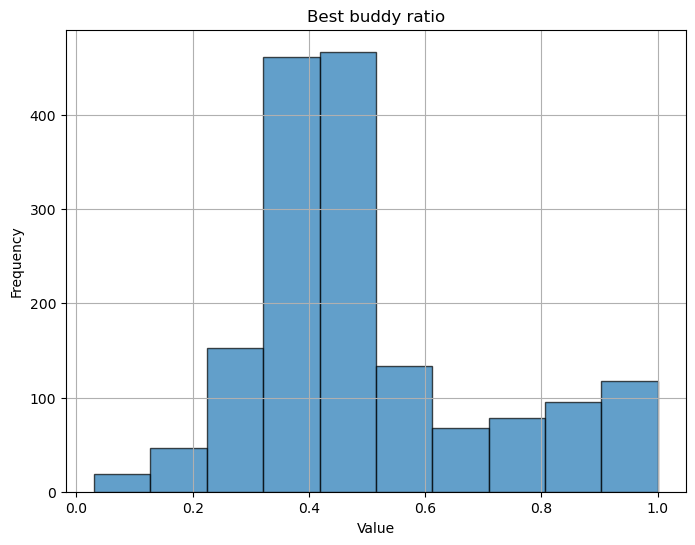

In [6]:
print(with_trans[with_trans['only_tm'] == True]['TMaligner_pocket_rmsd'].mean())
print(with_trans[with_trans['found_all'] == True]['TMaligner_pocket_rmsd'].mean())
def find_max_in_sublists(list_of_lists):
    try:
        return max([max(sublist) for sublist in list_of_lists])
    except:
        0

# Apply the function to the 'data' column and create a new column 'min_values'
with_trans['max_bbr'] = with_trans['bbr'].apply(find_max_in_sublists)
with_trans['max_bbr']
plt.figure(figsize=(8, 6))
plt.hist(with_trans['max_bbr'], bins=10, edgecolor='black', alpha=0.7)
plt.title('Best buddy ratio')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

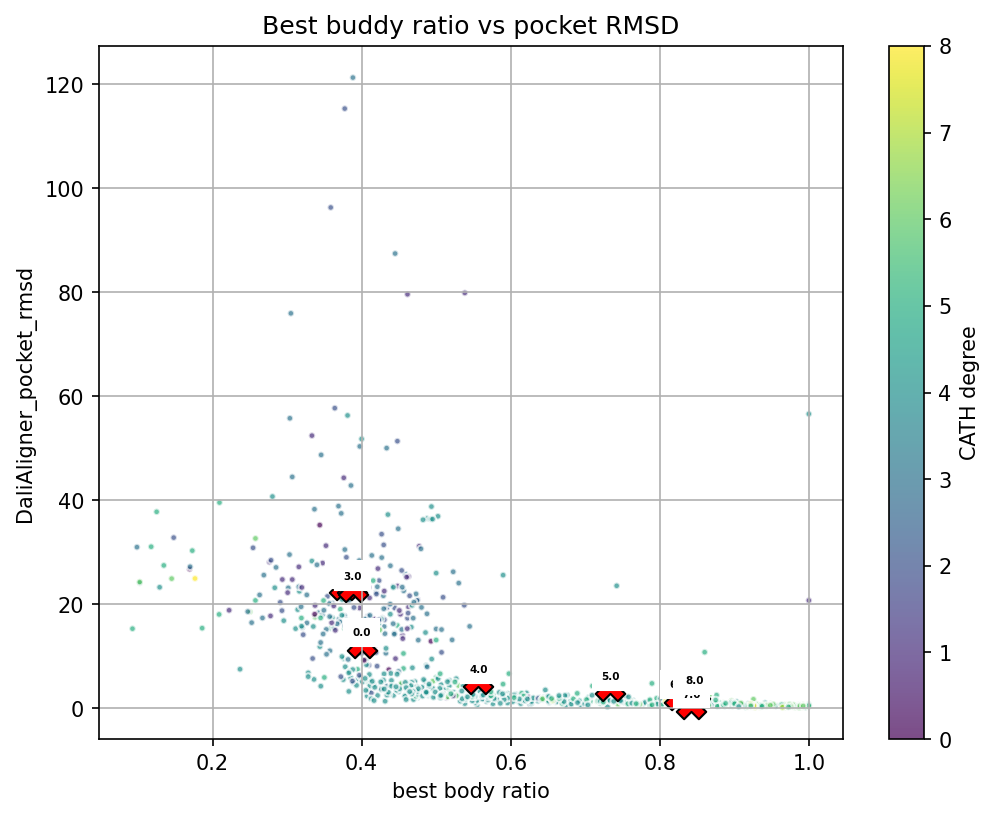

In [7]:
plt.figure(figsize=(8, 6), dpi=150)
scatter = plt.scatter(with_trans['max_bbr'], with_trans['DaliAligner_pocket_rmsd'], c=with_trans['cath_degree'], alpha=0.7, edgecolors='w', s=10)


# Overlay centroids
centroids = with_trans.groupby('cath_degree')[['max_bbr', 'DaliAligner_pocket_rmsd']].mean().reset_index()

# Annotate each centroid with its 'colors' value
for i, row in centroids.iterrows():
    plt.text(row['max_bbr'], row['DaliAligner_pocket_rmsd'] +1, f"{row['cath_degree']}", fontsize=5, ha='center', va='bottom', color='black', weight='bold', backgroundcolor='white')
plt.scatter(centroids['max_bbr'], centroids['DaliAligner_pocket_rmsd'], c='red', edgecolors='black', s=200, marker='X', label='Centroids')
plt.colorbar(scatter, label='CATH degree')

plt.title('Best buddy ratio vs pocket RMSD')
plt.xlabel('best body ratio')
plt.ylabel('DaliAligner_pocket_rmsd')
plt.grid(True)
plt.show()

## CATH degree and pocket RMSD correlation

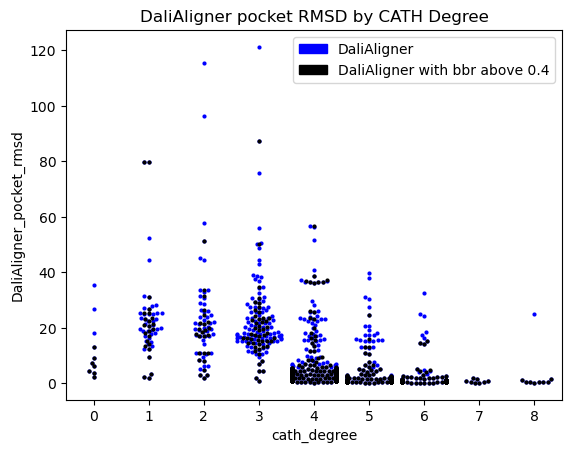

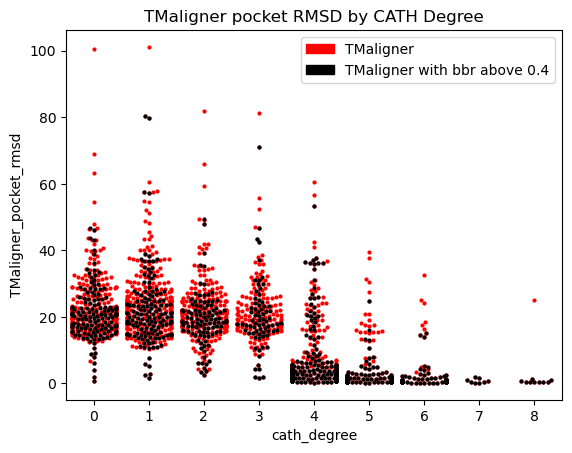

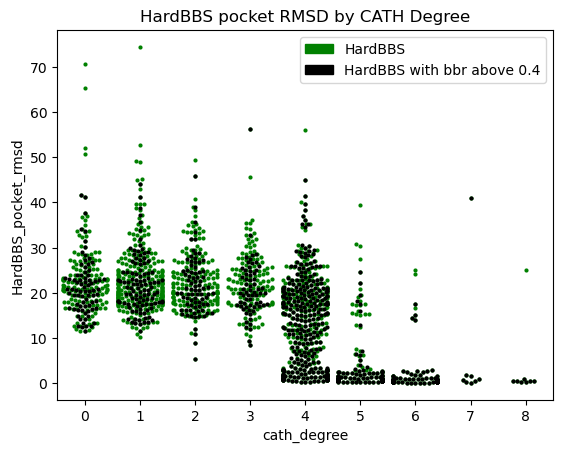

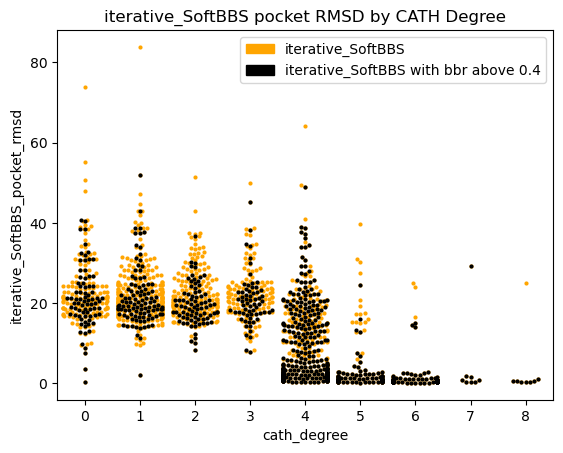

In [9]:
bbr_ratio = 0.4

for aligner_name, color in zip(['DaliAligner','TMaligner', 'HardBBS', "iterative_SoftBBS"], ['blue', 'red', 'green', 'orange']):   
    # color = "blue" if aligner_name == "DaliAligner" else "red"

    sns.swarmplot(data=with_trans, x="cath_degree", y=f"{aligner_name}_pocket_rmsd", size=3, label=aligner_name, color=color )
    sns.swarmplot(data=with_trans[ (with_trans['max_bbr'] > 0.4)], x="cath_degree", y=f"{aligner_name}_pocket_rmsd",color='black', size=3, label=aligner_name)

    plt.title(f"{aligner_name} pocket RMSD by CATH Degree")
    legend_handles = [
        Patch(color=color, label=aligner_name),
        Patch(color='black', label=f"{aligner_name} with bbr above {bbr_ratio}")
    ]

    plt.legend(handles=legend_handles)
    plt.show()

In [ ]:


with_trans['rmsd_diff'] = (with_trans['iterative_SoftBBS_pocket_rmsd'] - with_trans['TMaligner_pocket_rmsd'])

top_10_rows = with_trans.nlargest(50, 'rmsd_diff')

# rows_with_max_diff = with_trans[with_trans['rmsd_diff'] == max_rmsd_diff]

print(top_10_rows[['ref_protein', 'mov_protein', 'rmsd_diff']])


     ref_protein mov_protein  rmsd_diff
1447        1jg1        5ccv  37.031190
274         2ygq        4c16  33.577652
420         1ee9        1f8g  28.834548
165         3f5f        5tiz  28.586901
842         2dcu        3x1d  28.497604
1430        2wkp        5hzh  27.858815
1937        1nf3        2ywf  27.393194
146         2w9s        3slk  26.965532
843         3axs        3tm5  26.458170
471         1gth        1zdl  26.082636
23          2f8l        3ps9  25.415904
950         3eld        3tm5  25.303640
1086        1q20        3f5f  24.634804
1756        2epn        3fhq  24.545224
906         1f9w        2rio  24.456681
804         1ebd        4x4j  24.455685
1345        2iwc        5ced  23.956635
891         1e2f        1f9w  23.158713
1400        2egv        4b17  22.300197
489         3ojf        4aic  21.893384
827         1cf3        5j60  21.667824
886         3b8g        4nex  21.005666
1828        1c6s        1gjq  20.958992
960         2i99        2zb3  20.521457


/tmp/ipykernel_2114885/1922050962.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['rmsd_diff'] = (with_trans['iterative_SoftBBS_pocket_rmsd'] - with_trans['TMaligner_pocket_rmsd'])


: 

ValueError: Could not interpret value `SoftBBS_pocket_rmsd` for `y`. An entry with this name does not appear in `data`.

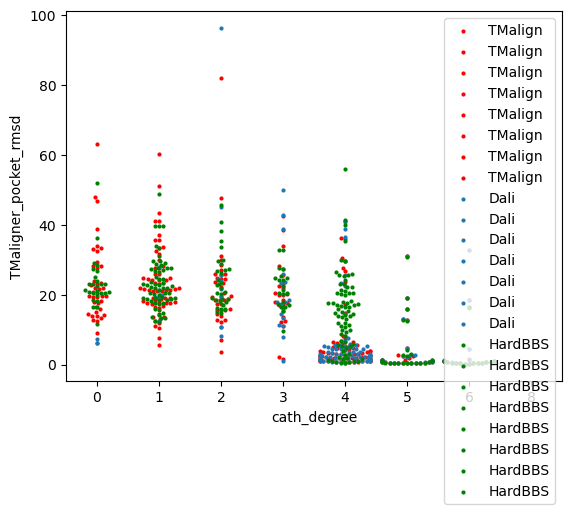

In [10]:
sns.swarmplot(data=with_trans[:300], x="cath_degree", y="TMaligner_pocket_rmsd", size=3, label='TMalign', color='red')
sns.swarmplot(data=with_trans[:300], x="cath_degree", y="DaliAligner_pocket_rmsd", size=3, label='Dali')
sns.swarmplot(data=with_trans[:300], x="cath_degree", y="HardBBS_pocket_rmsd", size=3, label='HardBBS', color='green')
sns.swarmplot(data=with_trans[:300], x="cath_degree", y="SoftBBS_pocket_rmsd", size=3, label='SoftBBS', color='green')
sns.swarmplot(data=with_trans[:300], x="cath_degree", y="iterative_SoftBBS_pocket_rmsd", size=3, label='SoftBBS', color='orange')
plt.title("Pocket RMSD by CATH Degree")
legend_handles = [
    Patch(color='blue', label='Dali'),
    Patch(color='red', label='TMalign'),
    Patch(color='green', label='HardBBS'),
    Patch(color='purple', label='SoftBBS'),
    Patch(color='orange', label='iterative_softBBS')
]

plt.legend(handles=legend_handles, title='Aligner')

In [11]:

def plot_medians(df, aligners: list, colors: list) -> None:
    plt.clf()
    median_values = {}
    sample_counts = {}
    for aligner_name, color in zip(aligners, colors):
        median_values[aligner_name] = df.groupby('cath_degree')[f"{aligner_name}_pocket_rmsd"].median()
        sample_counts[aligner_name] = df.groupby('cath_degree')[f"{aligner_name}_pocket_rmsd"].count()
        sns.pointplot(
            data=df,
            x="cath_degree",
            y=f"{aligner_name}_pocket_rmsd",
            color=color,
            estimator='median',
            markers='D',
            dodge=True,
            join=False,
            scale=0.5
        )
    max_median = max(max(medians) for medians in median_values.values())
    for cath_degree in sorted(with_trans['cath_degree'].unique()):
        medians = [median_values[aligner_name][cath_degree] for aligner_name in aligners]
        counts = [sample_counts[aligner_name][cath_degree] for aligner_name in aligners]
        y_offsets = [1.0 + i for i in range(0, len(aligners))]  # Adjust these values for vertical spacing
        
        for i, (aligner_name, color) in enumerate(zip(aligners, colors)):
            plt.text(
                x=cath_degree,  # x coordinate (cath_degree)
                y= max_median + 1 + y_offsets[i],  # y coordinate (fixed offset above the highest median)
                s=f"{medians[i]:.2f}",  # Median value rounded to 2 decimals
                color=color,
                fontsize=8,
                ha='center',
                va='bottom'  # Align text to be just above the point
            )
            # Annotate the sample count below the median value
        plt.text(
            x=cath_degree,  # x coordinate (cath_degree)
            y=max_median + 1 + y_offsets[-1] + 1,  # y coordinate (fixed offset below the median value)
            s=f"n={counts[i]}",  # Sample count
            color='black',
            fontsize=8,
            ha='center',
            va='bottom'  # Align text to be just below the median value
        )
    plt.ylabel("Mean Pocket RMSD")
    plt.title("Mean Pocket RMSD by CATH Degree")
    linewidth = 0.001
    median_legend_handles = []
    for aligner_name, color in zip(aligners, colors):
        median_legend_handles.append(Patch(color=color, linestyle='None', label=aligner_name, linewidth=linewidth))
    plt.ylim(0, max_median + 15)  
    plt.legend(handles=median_legend_handles)
    plt.show()

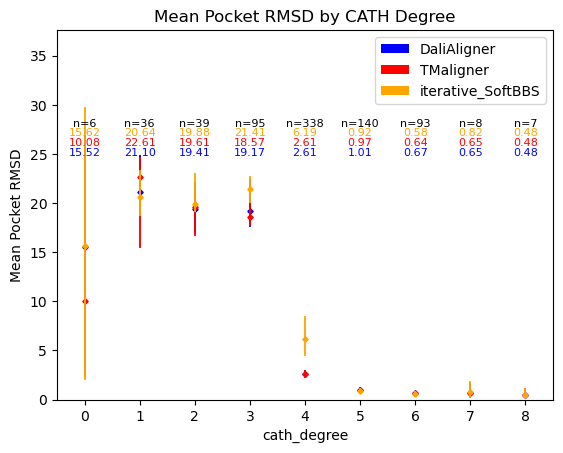

: 

In [12]:
plot_medians(with_trans[with_trans['found_all'] == True], ['DaliAligner','TMaligner', "iterative_SoftBBS"], ['blue', 'red', 'orange'])

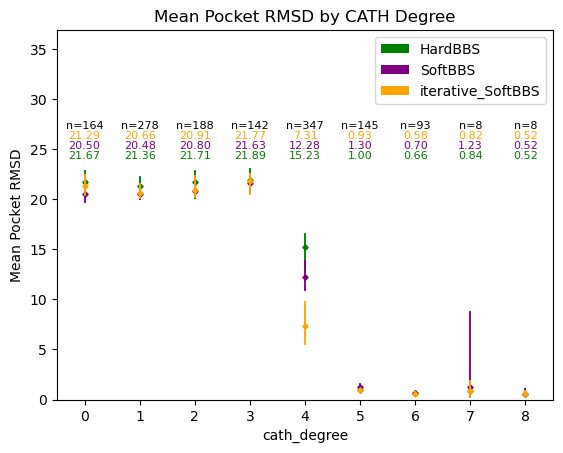

In [ ]:
plot_medians(with_trans[with_trans['found_softBBS'] == True], ['HardBBS','SoftBBS', "iterative_SoftBBS"], ['green', 'purple', 'orange'])

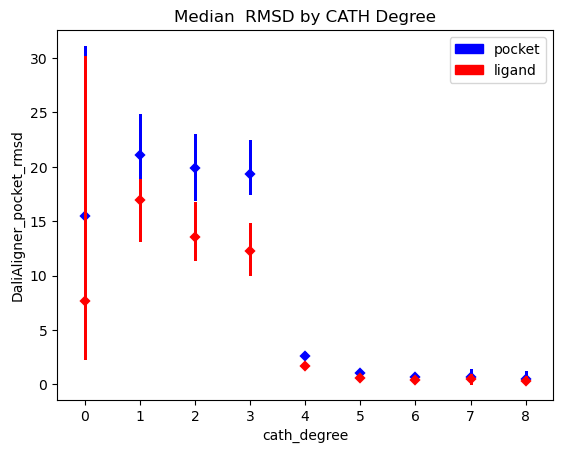

In [ ]:
for domain in ['pocket_rmsd','ligand_rmsd']:
    color = "blue" if domain == "pocket_rmsd" else "red"

    sns.pointplot(
        data=with_trans[with_trans['found_all'] == True],
        x="cath_degree",
        y=f"DaliAligner_{domain}",
        color=color,
        estimator='median',
        markers='D',
        dodge=True,
        join=False,
        
        scale=0.8
    )

plt.title("Median  RMSD by CATH Degree")
median_legend_handles = [
    Patch(color='blue', linestyle='None', label='pocket'),
    Patch(color='red', linestyle='None', label='ligand')
]
plt.legend(handles=median_legend_handles)
plt.show()

In [ ]:
with_trans['less_than_2'] = with_trans["DaliAligner_pocket_rmsd"] < 4
print((with_trans.groupby("cath_degree")["less_than_2"]).mean())
with_trans['less_than_2_tm'] = with_trans["TMaligner_pocket_rmsd"] < 4
(with_trans.groupby("cath_degree")["less_than_2_tm"]).mean()

cath_degree
0    0.007812
1    0.009174
2    0.013216
3    0.012048
4    0.670918
5    0.760234
6    0.888889
7    1.000000
8    0.800000
Name: less_than_2, dtype: float64


/tmp/ipykernel_2114885/3209341117.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['less_than_2'] = with_trans["DaliAligner_pocket_rmsd"] < 4
/tmp/ipykernel_2114885/3209341117.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['less_than_2_tm'] = with_trans["TMaligner_pocket_rmsd"] < 4


cath_degree
0    0.007812
1    0.009174
2    0.013216
3    0.018072
4    0.686224
5    0.789474
6    0.888889
7    1.000000
8    0.900000
Name: less_than_2_tm, dtype: float64

## Analays examples

In [ ]:
dali_df = with_trans[(with_trans['cath_degree'] < 2) & (with_trans['n_transformations'] ==1) & (with_trans['n_transformations'] ==1)]
sorted_df = dali_df.sort_values(by='rmsd', ascending=True)

# Select the top 'h' rows
dali_df[['Ligand_ID', 'ref_protein', 'mov_protein', 'DaliAligner_pocket_rmsd', 'max_bbr', 'cath_degree', 'rmsd']].head(50)

,Ligand_ID,ref_protein,mov_protein,DaliAligner_pocket_rmsd,max_bbr,cath_degree,rmsd
2,NAP,1afs,6c8w,NaN,0.304207,1,-1.0
4,PLP,1bjo,4beu,NaN,0.401015,1,-1.0
5,P6F,3t2d,5tkl,NaN,0.416667,0,-1.0
7,GTP,4zke,6ogz,NaN,0.342857,1,-1.0
21,BDP,3im0,4x8r,NaN,0.491979,0,-1.0
22,NAP,1ah0,3pdu,NaN,0.312169,1,-1.0
27,PLP,1b54,1j32,NaN,0.458824,1,-1.0
29,ASC,3fxr,4twl,NaN,0.410959,1,-1.0
33,IHP,2fvv,4lv7,NaN,0.388626,1,-1.0
34,GAL,2j5z,3oo6,NaN,0.449153,1,-1.0
